In [1]:
import h5py
import requests
import sys
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from mesma.core.mesma import MesmaCore, MesmaModels
from pathlib import Path

# Import custom utility functions
wrkspc = Path.cwd().parent
if str(wrkspc) not in sys.path:
    sys.path.insert(0, str(wrkspc))

import utils.tanager_utils

## Data Preparation
This section will walk through downloading the Tanager scene directly from the public STAC endpoint, georeferencing the hyperspectral cube, and plotting an RGB composite.

### Download Orthorectified Surface Reflectance Image

In [2]:
# Download the image to the data folder
url = "https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250724_190927_83_4001_ortho_sr_hdf5.h5"
output = Path(r"../data/images/ortho_sr_hdf5.h5")
output.parent.mkdir(parents=True, exist_ok=True)

if output.exists():
    print(f"Surface reflectance image saved in '{output}'.")
else:
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(output, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    print(f"Surface reflectance image downloaded to '{output}'.")

Surface reflectance image saved in '..\data\images\ortho_sr_hdf5.h5'.


### Load the image and plot an RGB composite with the current fire perimeter
Using the Tanager image date and Public Information Map from the Monroe Canyon Fire for the same day, a general fire perimeter was digitized to be used in this analysis. During an active fire, the Incident Management Team will frequently update the fire perimeter in GIS using thermal imagery, drone flights, and observers on the incident. 

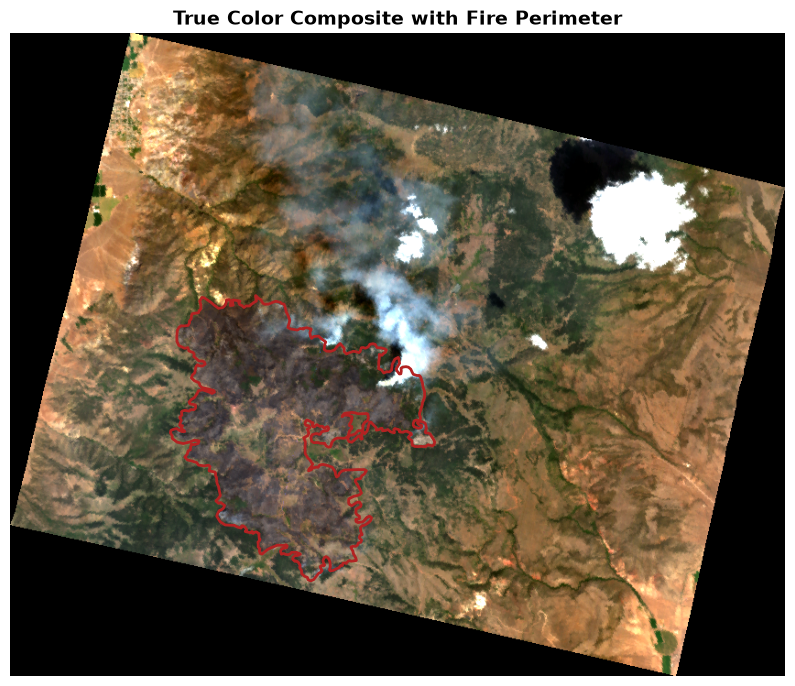

In [ ]:
# Load the image
with h5py.File(output) as img:
    # Load surface reflectance dataset
    img_sr = img['/HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance']

    # Extract known red, green, and blue band indices from the stack
    rb = img_sr[54, :, :].astype(np.float32)
    gb = img_sr[34, :, :].astype(np.float32)
    bb = img_sr[16, :, :].astype(np.float32)

    # Extract georeferencing information
    geoinfo = utils.tanager_utils.georeference_h5(img)

# Stack bands
rgb_img = np.dstack((rb, gb, bb))
# Handle nodata
rgb_img[rgb_img < 0] = 0 

# Apply a percentile stretch for better visualization
p2, p98 = np.percentile(rgb_img, (2, 98))
rgb_img_stretched = np.clip((rgb_img - p2) / (p98 - p2), 0, 1)

# Load the digitized fire perimeter
perimeter_path = Path(r"../data/gis/monroe_canyon_fire_perim_20250724.shp")
perim = gpd.read_file(perimeter_path).to_crs(geoinfo["crs"])

# Plot an RGB composite
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(
    rgb_img_stretched,
    extent=[geoinfo["xmin"], geoinfo["xmax"], geoinfo["ymin"], geoinfo["ymax"],],
)
perim.plot(
    ax=ax, 
    facecolor="none", 
    edgecolor="firebrick", 
    linewidth=2)
plt.title("True Color Composite with Fire Perimeter", fontsize=14, fontweight='bold')
plt.axis("off")
plt.show()

### Create Cloud, Active Fire, and Smoke Mask

Use Tanager's out of the box cloud masking, as well as some additional masks customized for this analysis. 

We will create an active fire mask which looks for pixels with a reflectance value > 1.0, indicating they are a reflectance **source**. Additionally, we will use the smoke mask generated in notebook 1.

The resulting image will contain clear pixels with no smoke or active fire, filtered to Tanager's good wavelengths for surface reflectance.

### Clip the masked cube to the fire perimeter AOI